Car Price Dataset
    Year  Kilometers_Driven  Engine_CC  Price_Lakh
0   2015              80000       1000         3.2
1   2016              75000       1200         3.5
2   2017              65000       1200         4.2
3   2018              55000       1500         5.0
4   2019              45000       1500         6.0
5   2020              35000       1600         7.0
6   2021              25000       1600         8.0
7   2022              15000       1800        10.0
8   2017              70000       1200         4.0
9   2019              40000       1500         6.5
10  2016              85000       1000         3.0
11  2018              60000       1400         5.2
12  2020              30000       1600         7.5
13  2021              20000       1800         9.0
14  2015              90000       1000         2.8
15  2022              10000       2000        11.0
16  2019              50000       1500         6.2
17  2017              72000       1200         4.0
18  2020     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


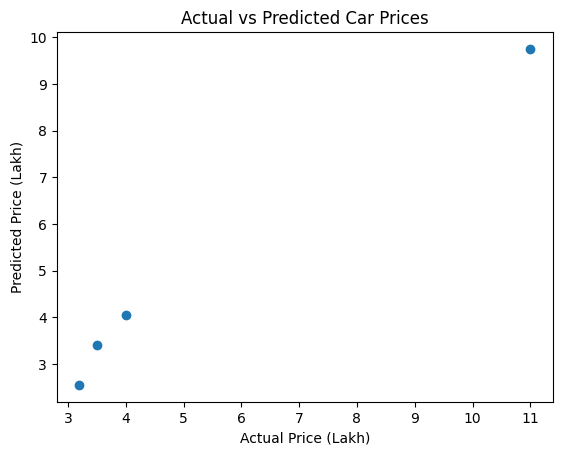

In [ ]:
# Car Price Prediction Model using Python
# Aim: Predict the price of a car using Linear Regression.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# STEP 1: Create a basic car dataset
# ---------------------------------------------------------

data = {
    'Year': [
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2017, 2019,
        2016, 2018, 2020, 2021, 2015,
        2022, 2019, 2017, 2020, 2021
    ],

    'Kilometers_Driven': [
        80000, 75000, 65000, 55000, 45000,
        35000, 25000, 15000, 70000, 40000,
        85000, 60000, 30000, 20000, 90000,
        10000, 50000, 72000, 28000, 18000
    ],

    'Engine_CC': [
        1000, 1200, 1200, 1500, 1500,
        1600, 1600, 1800, 1200, 1500,
        1000, 1400, 1600, 1800, 1000,
        2000, 1500, 1200, 1600, 1800
    ],

    'Price_Lakh': [
        3.2, 3.5, 4.2, 5.0, 6.0,
        7.0, 8.0, 10.0, 4.0, 6.5,
        3.0, 5.2, 7.5, 9.0, 2.8,
        11.0, 6.2, 4.0, 7.8, 9.2
    ]
}

df = pd.DataFrame(data)

print("Car Price Dataset")
print("=" * 50)
print(df)


# ---------------------------------------------------------
# STEP 2: Select input features and target
# ---------------------------------------------------------

X = df[
    ['Year', 'Kilometers_Driven', 'Engine_CC']
]

y = df['Price_Lakh']


# ---------------------------------------------------------
# STEP 3: Split dataset into training and testing data
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 4: Create Linear Regression model
# ---------------------------------------------------------

model = LinearRegression()


# ---------------------------------------------------------
# STEP 5: Train the model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# STEP 6: Predict test data
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# STEP 7: Display model results
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("CAR PRICE PREDICTION RESULTS")
print("=" * 50)

print("\nActual vs Predicted Price:")

for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual: ₹",
        round(actual, 2),
        "Lakh\tPredicted: ₹",
        round(predicted, 2),
        "Lakh"
    )


# ---------------------------------------------------------
# STEP 8: Calculate performance
# ---------------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error (MSE):",
      round(mse, 4))

print("R² Score:",
      round(r2, 4))


# ---------------------------------------------------------
# STEP 9: Display coefficients
# ---------------------------------------------------------

print("\nModel Coefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(
        feature,
        ":",
        round(coefficient, 4)
    )

print("\nIntercept:",
      round(model.intercept_, 4))


# ---------------------------------------------------------
# STEP 10: Predict price of a new car
# ---------------------------------------------------------

new_car = np.array([
    [2021, 30000, 1500]
])

predicted_price = model.predict(new_car)

print("\n" + "=" * 50)
print("NEW CAR PRICE PREDICTION")
print("=" * 50)

print("\nCar Details:")
print("Year: 2021")
print("Kilometers Driven: 30,000")
print("Engine: 1500 CC")

print(
    "\nPredicted Price: ₹",
    round(predicted_price[0], 2),
    "Lakh"
)


# ---------------------------------------------------------
# STEP 11: Plot Actual vs Predicted Prices
# ---------------------------------------------------------

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price (Lakh)")
plt.ylabel("Predicted Price (Lakh)")
plt.title("Actual vs Predicted Car Prices")

plt.show()